# Cardiovascular Disease Prediction

## Context and Project Goal

The dataset comes from a cardiovascular study. The goal is to build an interpretable logistic regression model that estimates whether a patient is at risk of developing coronary heart disease (CHD) within 10 years.

The notebook follows the same overall structure as the hands-on modeling task: preprocessing review, exploratory analysis, feature selection, logistic regression modeling, metric interpretation, threshold optimization, coefficient interpretation, and final recommendations.

The main upgrade is workflow quality. The notebook is self-contained for review, so the evaluator can see the full path from raw data to model interpretation in one place.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)
RAW_PATH = PROJECT_DIR / "data" / "train.csv"
CLEANED_PATH = OUTPUT_DIR / "cardiovascular_train_cleaned.csv"

## Data Preprocessing

The cleaning code is included in this notebook so the full workflow is easy to review from one place.

The cleaning step standardizes column names, standardizes categorical values, validates core assumptions, and adds deterministic features:

- `pulse_pressure`
- `mean_arterial_pressure`
- `age_group`
- `bp_stage`
- `smoking_intensity`
- `is_heavy_smoker`
- `has_high_glucose`
- `has_high_cholesterol`
- `log_cigs_per_day`
- `log_glucose`

Missing numeric values are intentionally left as missing in the cleaned CSV. Imputation and scaling happen later inside the scikit-learn model pipeline, which prevents train/test leakage.

In [2]:
column_renames = {
    "cigsPerDay": "cigs_per_day",
    "BPMeds": "bp_meds",
    "prevalentStroke": "prevalent_stroke",
    "prevalentHyp": "prevalent_hyp",
    "totChol": "total_cholesterol",
    "sysBP": "systolic_bp",
    "diaBP": "diastolic_bp",
    "BMI": "bmi",
    "heartRate": "heart_rate",
    "TenYearCHD": "ten_year_chd",
}


def threshold_flag(series, threshold):
    return pd.Series(
        np.where(series.isna(), np.nan, series >= threshold),
        index=series.index,
        dtype="float",
    )


def prepare_data(raw_path=RAW_PATH, cleaned_path=CLEANED_PATH):
    cleaned = (
        pd.read_csv(raw_path)
        .rename(columns=column_renames)
        .drop(columns="id")
    )

    cleaned["sex"] = cleaned["sex"].astype(str).str.strip().str.upper()
    cleaned["is_smoking"] = cleaned["is_smoking"].astype(str).str.strip().str.title()

    cleaned["pulse_pressure"] = cleaned["systolic_bp"] - cleaned["diastolic_bp"]
    cleaned["mean_arterial_pressure"] = (
        cleaned["diastolic_bp"] + cleaned["pulse_pressure"] / 3
    )
    cleaned["age_group"] = pd.cut(
        cleaned["age"],
        bins=[0, 39, 49, 59, 120],
        labels=["Under 40", "40-49", "50-59", "60+"],
    )
    cleaned["bp_stage"] = pd.cut(
        cleaned["systolic_bp"],
        bins=[0, 120, 130, 140, 1000],
        labels=["Normal", "Elevated", "Stage 1", "Stage 2"],
        right=False,
    )
    cleaned["smoking_intensity"] = pd.cut(
        cleaned["cigs_per_day"],
        bins=[-0.1, 0, 10, 20, 1000],
        labels=["Non-smoker", "Light", "Moderate", "Heavy"],
    )
    cleaned["is_heavy_smoker"] = threshold_flag(cleaned["cigs_per_day"], 20)
    cleaned["has_high_glucose"] = threshold_flag(cleaned["glucose"], 126)
    cleaned["has_high_cholesterol"] = threshold_flag(
        cleaned["total_cholesterol"], 240
    )
    cleaned["log_cigs_per_day"] = np.log1p(cleaned["cigs_per_day"])
    cleaned["log_glucose"] = np.log1p(cleaned["glucose"])

    assert set(cleaned["ten_year_chd"].dropna().unique()).issubset({0, 1})
    assert set(cleaned["sex"].dropna().unique()).issubset({"F", "M"})
    assert set(cleaned["is_smoking"].dropna().unique()).issubset({"No", "Yes"})
    assert cleaned["age"].between(18, 100).all()
    assert (cleaned["pulse_pressure"] > 0).all()
    assert not cleaned.duplicated().any()

    cleaned.to_csv(cleaned_path, index=False)
    return cleaned


df = prepare_data()

print(f"Dataset size: {df.shape[0]:,} rows and {df.shape[1]:,} columns")

Dataset size: 3,390 rows and 26 columns


In [3]:
missing_summary = (
    df.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_rows")
)
missing_summary["missing_rate"] = missing_summary["missing_rows"] / len(df)

target_summary = (
    df["ten_year_chd"]
    .value_counts()
    .rename(index={0: "No CHD within 10 years", 1: "CHD within 10 years"})
    .to_frame("rows")
)
target_summary["share"] = target_summary["rows"] / len(df)

data_quality_table = (
    missing_summary
    .reset_index(names="feature")
    .assign(missing_rate=lambda data: data["missing_rate"].map(lambda value: f"{value:.1%}"))
)

target_table = (
    target_summary
    .reset_index(names="target_class")
    .assign(share=lambda data: data["share"].map(lambda value: f"{value:.1%}"))
)

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=["Feature", "Missing rows", "Missing rate"],
                fill_color="#1f2937",
                font=dict(color="white"),
                align="left",
            ),
            cells=dict(
                values=[
                    data_quality_table["feature"],
                    data_quality_table["missing_rows"],
                    data_quality_table["missing_rate"],
                ],
                align="left",
            ),
        )
    ]
)
fig.update_layout(title="Interactive Missing-Value Summary", height=360)
fig.write_html(CHART_DIR / "interactive_missing_value_summary.html")
fig.show()

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=["Target class", "Rows", "Share"],
                fill_color="#1f2937",
                font=dict(color="white"),
                align="left",
            ),
            cells=dict(
                values=[
                    target_table["target_class"],
                    target_table["rows"],
                    target_table["share"],
                ],
                align="left",
            ),
        )
    ]
)
fig.update_layout(title="Interactive Target-Balance Summary", height=260)
fig.write_html(CHART_DIR / "interactive_target_balance_summary.html")
fig.show()

The dataset contains 3,390 patients, and 511 of them have a recorded 10-year CHD event, a positive rate of 15.1%. This imbalance makes plain accuracy misleading: a model can look strong by over-predicting the 84.9% majority class, so evaluation must focus on how well the model identifies the minority CHD-risk group.

## Exploratory Data Analysis

Exploratory analysis focuses on risk patterns that are strong enough to justify inclusion in an interpretable model. Age, blood pressure, smoking intensity, glucose, cholesterol, and sex are emphasized because they are clinically meaningful and explainable to both technical and non-technical reviewers.

In [4]:
def summarize_chd_rate(group_column):
    return (
        df.groupby(group_column, observed=True)
        .agg(patients=("ten_year_chd", "size"), chd_rate=("ten_year_chd", "mean"))
        .reset_index()
    )


risk_by_group = summarize_chd_rate("age_group")
risk_by_bp = summarize_chd_rate("bp_stage")
risk_by_smoking = summarize_chd_rate("smoking_intensity")

risk_summary = pd.concat(
    [
        risk_by_group.rename(columns={"age_group": "segment"}).assign(category="Age group"),
        risk_by_bp.rename(columns={"bp_stage": "segment"}).assign(category="Blood pressure stage"),
        risk_by_smoking.rename(columns={"smoking_intensity": "segment"}).assign(category="Smoking intensity"),
    ],
    ignore_index=True,
)
risk_summary["chd_rate_label"] = risk_summary["chd_rate"].map(lambda value: f"{value:.1%}")

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=["Category", "Segment", "Patients", "CHD rate"],
                fill_color="#1f2937",
                font=dict(color="white"),
                align="left",
            ),
            cells=dict(
                values=[
                    risk_summary["category"],
                    risk_summary["segment"],
                    risk_summary["patients"],
                    risk_summary["chd_rate_label"],
                ],
                align="left",
            ),
        )
    ]
)
fig.update_layout(title="Interactive CHD Rate Summary by Segment", height=520)
fig.write_html(CHART_DIR / "interactive_chd_rate_summary.html")
fig.show()

In [5]:
fig = px.bar(
    risk_summary,
    x="segment",
    y="chd_rate",
    color="category",
    facet_col="category",
    text="chd_rate_label",
    title="10-Year CHD Rate by Age, Blood Pressure, and Smoking Segments",
    labels={
        "segment": "",
        "chd_rate": "10-year CHD rate",
        "category": "Segment type",
    },
    color_discrete_sequence=["#2563eb", "#16a34a", "#f59e0b"],
)
fig.update_yaxes(tickformat=".0%")
fig.update_xaxes(tickangle=25)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_layout(template="plotly_white", height=520, showlegend=False)
fig.write_html(CHART_DIR / "interactive_chd_rates_by_key_groups.html")
fig.show()

CHD risk rises sharply with age: the 60+ group has a substantially higher event rate than patients under 40. Blood pressure also shows a clinically useful gradient, with Stage 2 systolic BP carrying higher observed risk than normal BP; smoking intensity adds another behavioral signal, especially for heavier smoking segments.

In [6]:
correlation_features = [
    "age",
    "log_cigs_per_day",
    "total_cholesterol",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "heart_rate",
    "log_glucose",
    "pulse_pressure",
    "ten_year_chd",
]

corr = df[correlation_features].corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Interactive Correlation Map for Clinical and Engineered Features",
)
fig.update_layout(template="plotly_white", height=720)
fig.write_html(CHART_DIR / "interactive_clinical_feature_correlation_heatmap.html")
fig.show()

The correlation view supports a compact feature set rather than adding every related measurement. `systolic_bp` is retained as the main blood-pressure level feature, while `pulse_pressure` captures pressure spread; adding `diastolic_bp` and `mean_arterial_pressure` as well would make the model harder to explain without adding clearly distinct information.

## Model Preparation

Logistic regression is used because it is required by the assignment and remains interpretable: coefficients can be translated into odds ratios.

Variable selection is based on three criteria:

- Clinical relevance to CHD risk.
- Evidence from EDA.
- Avoiding unnecessary duplication among highly related measurements.

Transformations:

- Median imputation for numeric features.
- Most-frequent imputation for categorical features.
- Standard scaling for numeric features.
- One-hot encoding for categorical features.
- Log transforms for skewed cigarette and glucose values.

In [7]:
target = "ten_year_chd"

model_features = [
    "age",
    "sex",
    "education",
    "is_smoking",
    "log_cigs_per_day",
    "bp_meds",
    "prevalent_stroke",
    "prevalent_hyp",
    "diabetes",
    "total_cholesterol",
    "systolic_bp",
    "bmi",
    "heart_rate",
    "log_glucose",
    "pulse_pressure",
    "is_heavy_smoker",
    "has_high_glucose",
    "has_high_cholesterol",
]

X = df[model_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

numeric_features = [col for col in model_features if col not in ["sex", "is_smoking"]]
categorical_features = ["sex", "is_smoking"]

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Training CHD rate: {y_train.mean():.1%}")
print(f"Test CHD rate: {y_test.mean():.1%}")

Training rows: 2,712
Test rows: 678
Training CHD rate: 15.1%
Test CHD rate: 15.0%


## Logistic Regression Model

The model is tuned with stratified 5-fold cross-validation. Average precision is used during tuning because it evaluates how well the model ranks the minority positive class in an imbalanced dataset.

In [8]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("logreg", LogisticRegression(max_iter=2000, solver="liblinear")),
    ]
)

param_grid = {
    "logreg__C": np.logspace(-3, 2, 12),
    "logreg__penalty": ["l1", "l2"],
    "logreg__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    model_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validated average precision: {grid_search.best_score_:.3f}")

Best parameters:
{'logreg__C': np.float64(0.0657933224657568), 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l1'}
Best cross-validated average precision: 0.354


## Metric Choice and Optimal Threshold

For this problem, recall matters more than raw accuracy because missing a high-risk CHD patient is more harmful than sending a lower-risk patient for follow-up. Precision still matters because a screening process with too many false positives becomes noisy and expensive.

F2 is therefore used to choose the classification threshold. F2 weights recall more heavily than precision, which fits a preventive healthcare screening context.

To avoid selecting the threshold on the final test set, out-of-fold probabilities are calculated on the training data, the F2-maximizing threshold is selected there, and that threshold is evaluated only once on the untouched test set.

In [9]:
oof_probabilities = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_probabilities)
beta = 2
f2_scores = (1 + beta**2) * precision * recall / (
    beta**2 * precision + recall + 1e-12
)

best_threshold_index = np.nanargmax(f2_scores[:-1])
optimal_threshold = float(thresholds[best_threshold_index])

print(f"Optimal F2 threshold from training folds: {optimal_threshold:.3f}")
print(f"Training-fold precision at threshold: {precision[best_threshold_index]:.3f}")
print(f"Training-fold recall at threshold: {recall[best_threshold_index]:.3f}")
print(f"Training-fold F2 at threshold: {f2_scores[best_threshold_index]:.3f}")

threshold_curve = pd.DataFrame(
    {
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
        "f2_score": f2_scores[:-1],
    }
)

fig = go.Figure()
for metric in ["precision", "recall", "f2_score"]:
    fig.add_trace(
        go.Scatter(
            x=threshold_curve["threshold"],
            y=threshold_curve[metric],
            mode="lines",
            name=metric.replace("_", " ").title(),
        )
    )
fig.add_vline(x=optimal_threshold, line_dash="dash", line_color="#dc2626")
fig.update_layout(
    title="Interactive Threshold Tradeoff",
    xaxis_title="Classification threshold",
    yaxis_title="Score",
    template="plotly_white",
    height=520,
)
fig.write_html(CHART_DIR / "interactive_threshold_tradeoff.html")
fig.show()

Optimal F2 threshold from training folds: 0.410
Training-fold precision at threshold: 0.223
Training-fold recall at threshold: 0.822
Training-fold F2 at threshold: 0.535


## Model Performance

The default `0.50` threshold is compared with the optimized F2 threshold. The optimized threshold should identify more actual CHD cases, while the default threshold should usually make fewer false-positive predictions.

In [10]:
test_probabilities = best_model.predict_proba(X_test)[:, 1]

def evaluate_threshold(name, threshold):
    predictions = (test_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    return {
        "threshold_type": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions),
        "f2_score": fbeta_score(y_test, predictions, beta=2),
        "specificity": tn / (tn + fp),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
    }

performance = pd.DataFrame(
    [
        evaluate_threshold("Default 0.50", 0.50),
        evaluate_threshold("Optimized F2", optimal_threshold),
    ]
)

roc_auc = roc_auc_score(y_test, test_probabilities)
average_precision = average_precision_score(y_test, test_probabilities)

performance.to_csv(OUTPUT_DIR / "model_performance_summary.csv", index=False)

print(f"Test ROC-AUC: {roc_auc:.3f}")
print(f"Test average precision: {average_precision:.3f}")
print(f"Positive-class baseline rate: {y_test.mean():.3f}")

performance_display = performance.copy()
metric_columns = [
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f2_score",
    "specificity",
]
performance_display[metric_columns] = performance_display[metric_columns].round(3)

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=[column.replace("_", " ").title() for column in performance_display.columns],
                fill_color="#1f2937",
                font=dict(color="white"),
                align="left",
            ),
            cells=dict(
                values=[performance_display[column] for column in performance_display.columns],
                align="left",
            ),
        )
    ]
)
fig.update_layout(title="Interactive Threshold Performance Summary", height=320)
fig.write_html(CHART_DIR / "interactive_threshold_performance_summary.html")
fig.show()

Test ROC-AUC: 0.726
Test average precision: 0.321
Positive-class baseline rate: 0.150


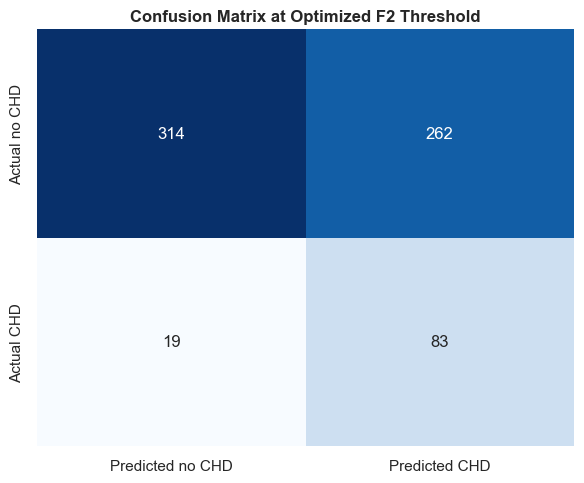

In [11]:
optimized_predictions = (test_probabilities >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, optimized_predictions)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted no CHD", "Predicted CHD"],
    yticklabels=["Actual no CHD", "Actual CHD"],
    ax=ax,
)
ax.set_title("Confusion Matrix at Optimized F2 Threshold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(CHART_DIR / "optimized_threshold_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

Lowering the threshold from 0.50 to about 0.41 increases true positives from 66 to 83 and reduces false negatives from 36 to 19. The tradeoff is an increase in false positives from 166 to 262, which is acceptable for a screening-oriented model because the output should prioritize follow-up rather than act as a diagnosis.

## Coefficient Interpretation

Because numeric variables are standardized, each numeric odds ratio describes the effect of a one-standard-deviation increase in that feature, holding the other model features constant. Categorical odds ratios compare against the omitted reference level.

In [12]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
coefficients = best_model.named_steps["logreg"].coef_[0]

coefficient_table = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "odds_ratio": np.exp(coefficients),
        }
    )
    .assign(abs_coefficient=lambda data: data["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
)

coefficient_table.to_csv(OUTPUT_DIR / "model_coefficients.csv", index=False)

coefficient_display = coefficient_table.head(15).copy()
coefficient_display["coefficient"] = coefficient_display["coefficient"].round(3)
coefficient_display["odds_ratio"] = coefficient_display["odds_ratio"].round(3)

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=["Feature", "Coefficient", "Odds ratio"],
                fill_color="#1f2937",
                font=dict(color="white"),
                align="left",
            ),
            cells=dict(
                values=[
                    coefficient_display["feature"],
                    coefficient_display["coefficient"],
                    coefficient_display["odds_ratio"],
                ],
                align="left",
            ),
        )
    ]
)
fig.update_layout(title="Interactive Top Coefficients Table", height=520)
fig.write_html(CHART_DIR / "interactive_model_coefficients_table.html")
fig.show()

In [13]:
top_coefficients = coefficient_table.head(10).copy()
top_coefficients["direction"] = np.where(
    top_coefficients["coefficient"] >= 0,
    "Higher CHD odds",
    "Lower CHD odds",
)

fig = px.bar(
    top_coefficients.sort_values("coefficient"),
    x="coefficient",
    y="feature",
    color="direction",
    orientation="h",
    title="Most Influential Logistic Regression Coefficients",
    labels={"coefficient": "Standardized coefficient", "feature": "Feature"},
    color_discrete_map={
        "Higher CHD odds": "#dc2626",
        "Lower CHD odds": "#2563eb",
    },
)
fig.update_layout(template="plotly_white", height=520)
fig.write_html(CHART_DIR / "interactive_model_coefficients.html")
fig.show()

The largest positive coefficients are age, systolic blood pressure, male sex, smoking exposure, high glucose, hypertension history, and total cholesterol. These variables align with the EDA and make the model explainable: the strongest predictors are not hidden technical artifacts but clinically recognizable risk factors.

## Conclusions and Actionable Insights

- The positive class is only 15.1%, so accuracy is not the lead metric; a majority-class model would already appear superficially strong.
- The optimized threshold is about 0.41, raising recall from 64.7% to 81.4% and reducing missed CHD cases from 36 to 19 in the test set.
- The model is best framed as follow-up prioritization, not diagnosis, because the higher recall comes with 262 false positives at the optimized threshold.

## Limitations

- The dataset is observational, so coefficients describe association rather than causation.
- Only 511 positive CHD cases are available, so the 0.41 threshold should be validated on external data before clinical use.
- Important predictors such as family history, diet, exercise, and detailed medication history are unavailable, limiting the model's clinical completeness.